In [1]:
# ส่วนที่ 1: นำเข้าไลบรารี โหลดข้อมูล และแยกชุดข้อมูล
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import seaborn as sns
from itertools import combinations

In [4]:
# อ่านข้อมูลจาก gestures_features.csv
df = pd.read_csv("/Users/aoyrzz/Desktop/hand_game/main_project/Extrack_feature/gestures_features.csv")
X = df.drop('label', axis=1).values
y = df['label'].values

# แยกชุดข้อมูลเป็น train และ test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# รายชื่อคลาส
classes = np.unique(y)
print("คลาสทั้งหมด:", classes)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# กำหนด distance_pairs สำหรับชื่อฟีเจอร์ (เหมือนใน extract_features.py)
key_points = [0, 4, 8, 12, 16, 20]  # wrist, thumb_tip, index_tip, middle_tip, ring_tip, pinky_tip
distance_pairs = list(combinations(key_points, 2))
print("Number of distance pairs:", len(distance_pairs))  # เพิ่มเพื่อยืนยัน

คลาสทั้งหมด: ['Back' 'Down' 'Go forward' 'Left' 'OK' 'Right' 'Stop' 'Up']
Train shape: (788, 17)
Test shape: (197, 17)
Number of distance pairs: 15


In [5]:
# ส่วนที่ 2: ฝึกโมเดลทั้งสาม
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

# SVM
svm = SVC(kernel='rbf', random_state=42, probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

In [6]:
# ส่วนที่ 3: คำนวณเมตริกประสิทธิภาพ
# คำนวณ Accuracy
rf_accuracy = accuracy_score(y_test, rf_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy Scores:")
print(f"Random Forest: {rf_accuracy:.4f}")
print(f"KNN: {knn_accuracy:.4f}")
print(f"SVM: {svm_accuracy:.4f}")

# คำนวณ Precision, Recall, F1-Score สำหรับแต่ละคลาส
rf_report = classification_report(y_test, rf_pred, output_dict=True)
knn_report = classification_report(y_test, knn_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)

# ดึงเมตริกสำหรับแต่ละคลาส
metrics = {'precision': {}, 'recall': {}, 'f1-score': {}}
for cls in classes:
    metrics['precision'][cls] = [rf_report[cls]['precision'], knn_report[cls]['precision'], svm_report[cls]['precision']]
    metrics['recall'][cls] = [rf_report[cls]['recall'], knn_report[cls]['recall'], svm_report[cls]['recall']]
    metrics['f1-score'][cls] = [rf_report[cls]['f1-score'], knn_report[cls]['f1-score'], svm_report[cls]['f1-score']]

Accuracy Scores:
Random Forest: 0.9797
KNN: 0.8122
SVM: 0.7766


In [7]:
print("\nPer-Class Metrics:")
for metric in ['precision', 'recall', 'f1-score']:
    print(f"\n{metric.capitalize()} per Class:")
    df_metric = pd.DataFrame(metrics[metric], index=['Random Forest', 'KNN', 'SVM']).T
    df_metric = df_metric.round(4)
    print(df_metric)


Per-Class Metrics:

Precision per Class:
            Random Forest     KNN     SVM
Back               1.0000  0.7500  0.0000
Down               1.0000  0.8571  1.0000
Go forward         1.0000  0.9091  0.8333
Left               0.9524  0.6129  0.5806
OK                 1.0000  0.9394  0.9394
Right              0.9615  0.7241  0.6562
Stop               0.9459  0.8684  0.8919
Up                 1.0000  0.8182  0.6897

Recall per Class:
            Random Forest     KNN     SVM
Back               0.9286  0.2143  0.0000
Down               1.0000  0.7500  0.6250
Go forward         1.0000  1.0000  1.0000
Left               0.9524  0.9048  0.8571
OK                 1.0000  1.0000  1.0000
Right              0.9615  0.8077  0.8077
Stop               1.0000  0.9429  0.9429
Up                 1.0000  0.9000  1.0000

F1-score per Class:
            Random Forest     KNN     SVM
Back               0.9630  0.3333  0.0000
Down               1.0000  0.8000  0.7692
Go forward         1.0000  0.9524  0

In [9]:
# คำนวณ Precision, Recall, F1-Score (macro-average) สำหรับแต่ละโมเดล
rf_report = classification_report(y_test, rf_pred, output_dict=True)
knn_report = classification_report(y_test, knn_pred, output_dict=True)
svm_report = classification_report(y_test, svm_pred, output_dict=True)

# สร้างตารางเมตริก
metrics = {
    'Model': ['Random Forest', 'KNN', 'SVM'],
    'Accuracy': [rf_accuracy, knn_accuracy, svm_accuracy],
    'Precision': [rf_report['macro avg']['precision'], knn_report['macro avg']['precision'], svm_report['macro avg']['precision']],
    'Recall': [rf_report['macro avg']['recall'], knn_report['macro avg']['recall'], svm_report['macro avg']['recall']],
    'F1-Score': [rf_report['macro avg']['f1-score'], knn_report['macro avg']['f1-score'], svm_report['macro avg']['f1-score']]
}

# สร้าง DataFrame และปัดทศนิยม
df_metrics = pd.DataFrame(metrics)
df_metrics[['Accuracy', 'Precision', 'Recall', 'F1-Score']] = df_metrics[['Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4)
df_metrics.set_index('Model', inplace=True)

# พิมพ์ตาราง
print("\nModel Performance Metrics (Macro-Average):")
print(df_metrics)


Model Performance Metrics (Macro-Average):
               Accuracy  Precision  Recall  F1-Score
Model                                               
Random Forest    0.9797     0.9825  0.9803    0.9811
KNN              0.8122     0.8099  0.8149    0.7888
SVM              0.7766     0.6989  0.7791    0.7246


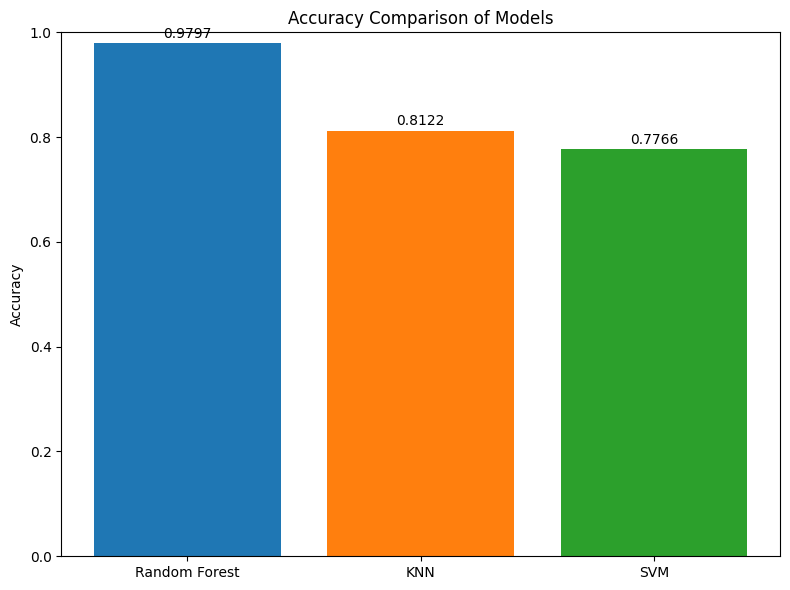

In [17]:
# ส่วนที่ 4: พล็อต Bar Plot สำหรับ Accuracy
plt.figure(figsize=(8, 6))
models = ['Random Forest', 'KNN', 'SVM']
accuracies = [rf_accuracy, knn_accuracy, svm_accuracy]
plt.bar(models, accuracies, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Accuracy Comparison of Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center')
plt.tight_layout()
plt.savefig('accuracy_comparison.png')
plt.show()

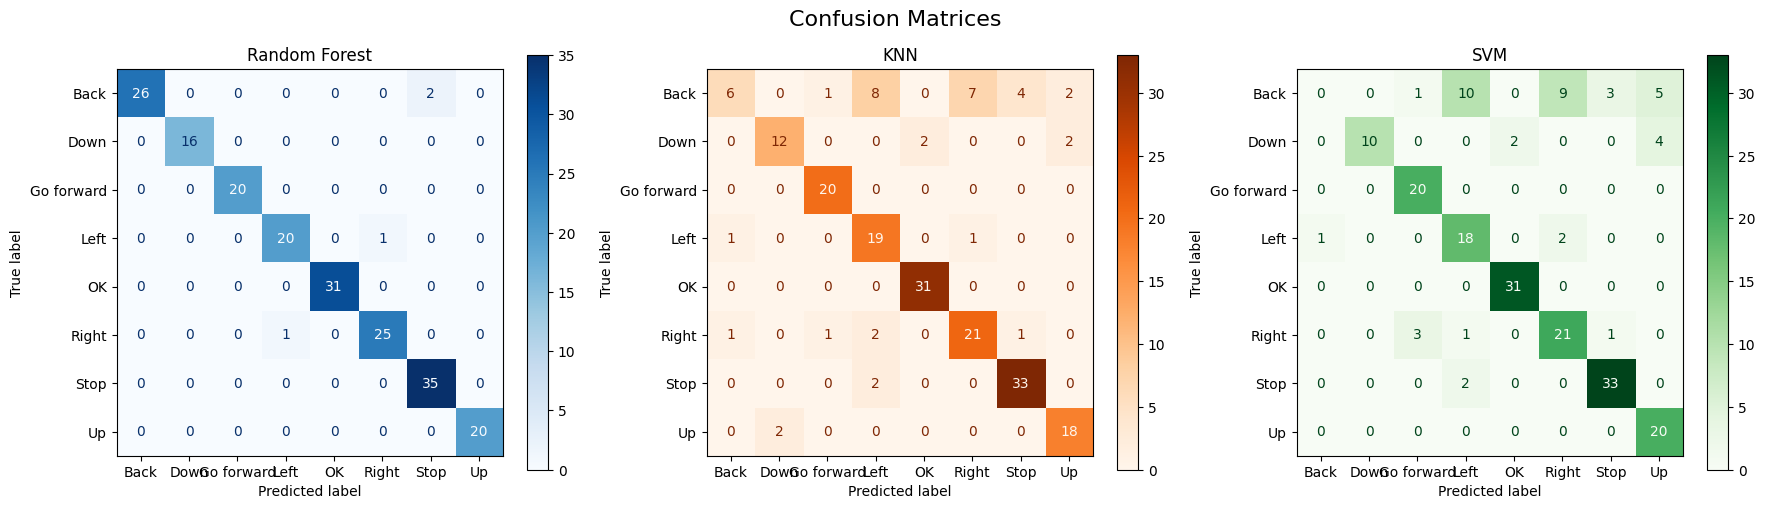

In [18]:
# ส่วนที่ 5: พล็อต Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16)

# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=classes)
disp_rf.plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Random Forest')

# KNN
cm_knn = confusion_matrix(y_test, knn_pred)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=classes)
disp_knn.plot(ax=axes[1], cmap='Oranges')
axes[1].set_title('KNN')

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=classes)
disp_svm.plot(ax=axes[2], cmap='Greens')
axes[2].set_title('SVM')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

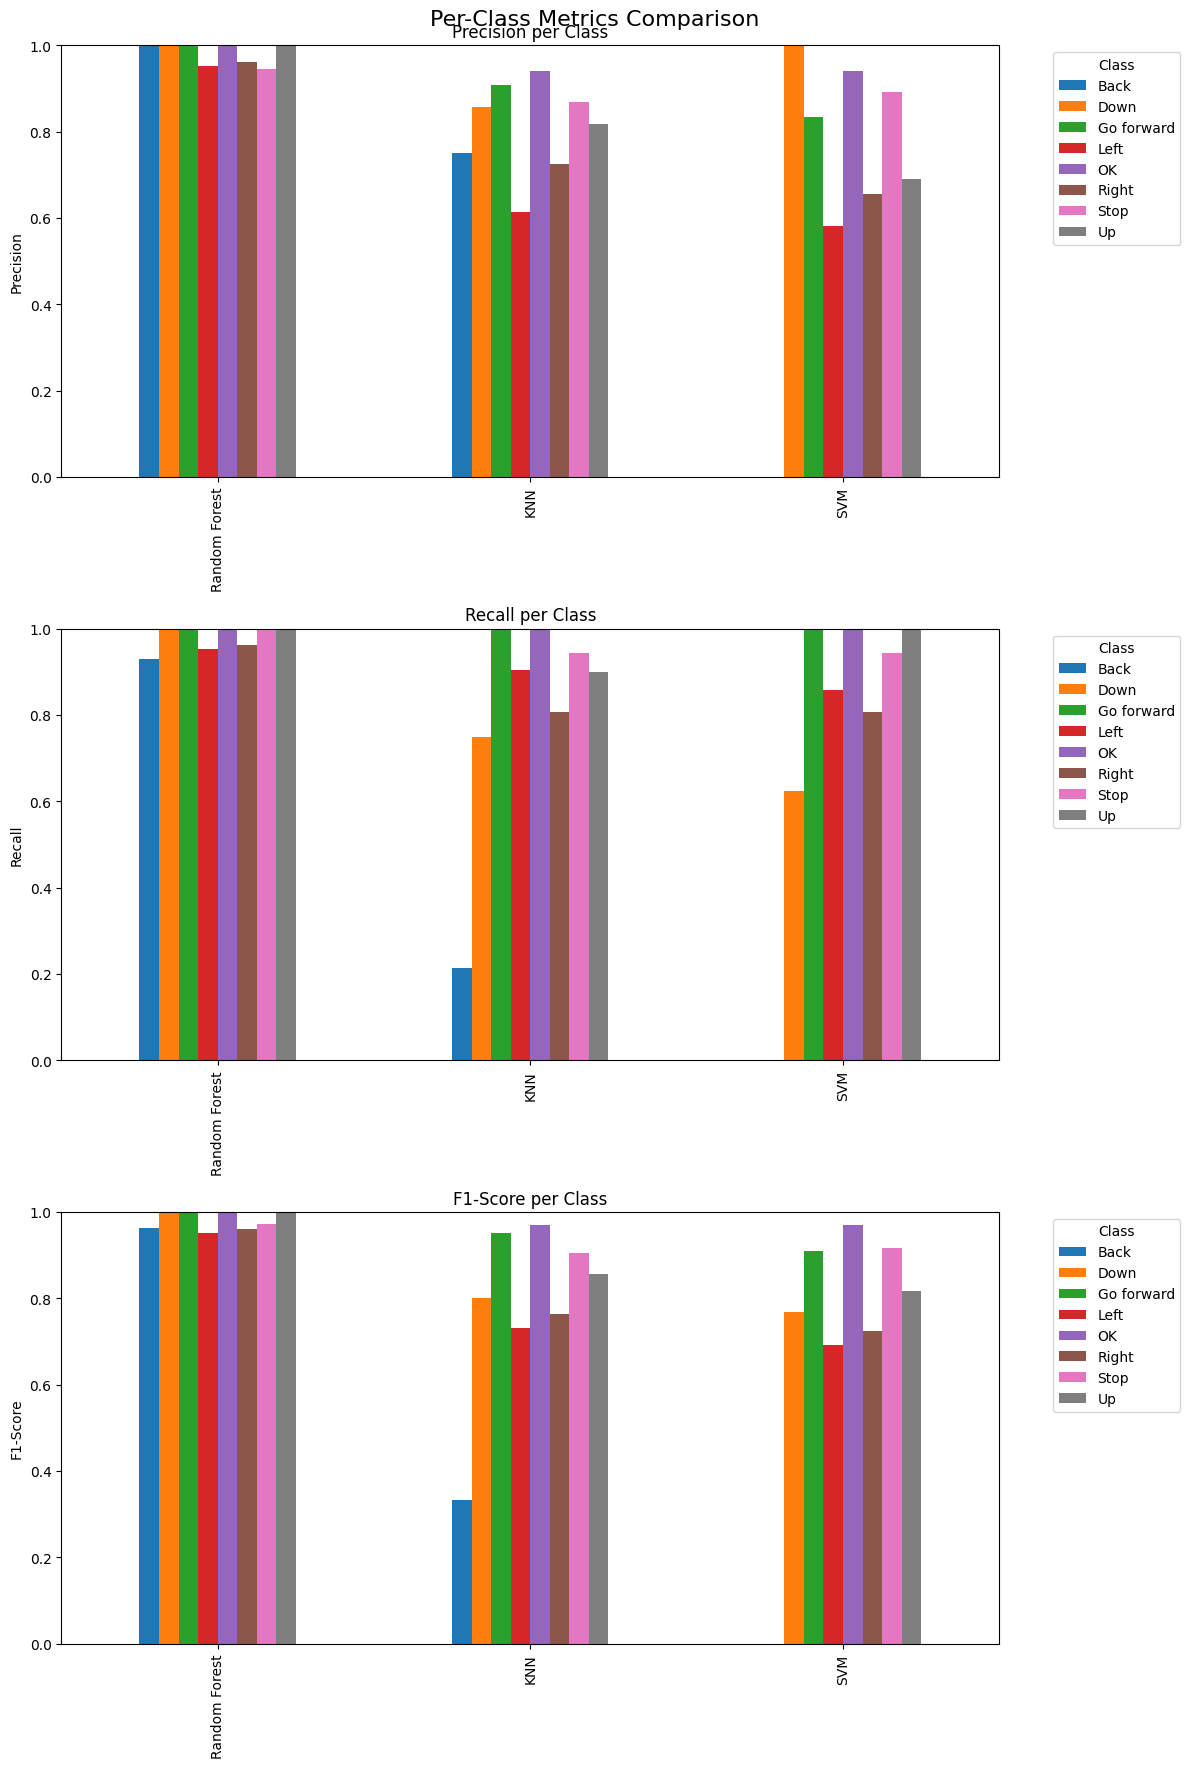

In [19]:
# ส่วนที่ 6: พล็อต Bar Plot สำหรับ Precision, Recall, F1-Score แยกตามคลาส
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
fig.suptitle('Per-Class Metrics Comparison', fontsize=16)

# Precision
prec_data = pd.DataFrame(metrics['precision'], index=models)
prec_data.plot(kind='bar', ax=axes[0], color=sns.color_palette("tab10", len(classes)))
axes[0].set_title('Precision per Class')
axes[0].set_ylabel('Precision')
axes[0].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].set_ylim(0, 1)

# Recall
rec_data = pd.DataFrame(metrics['recall'], index=models)
rec_data.plot(kind='bar', ax=axes[1], color=sns.color_palette("tab10", len(classes)))
axes[1].set_title('Recall per Class')
axes[1].set_ylabel('Recall')
axes[1].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].set_ylim(0, 1)

# F1-Score
f1_data = pd.DataFrame(metrics['f1-score'], index=models)
f1_data.plot(kind='bar', ax=axes[2], color=sns.color_palette("tab10", len(classes)))
axes[2].set_title('F1-Score per Class')
axes[2].set_ylabel('F1-Score')
axes[2].legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('per_class_metrics.png')
plt.show()

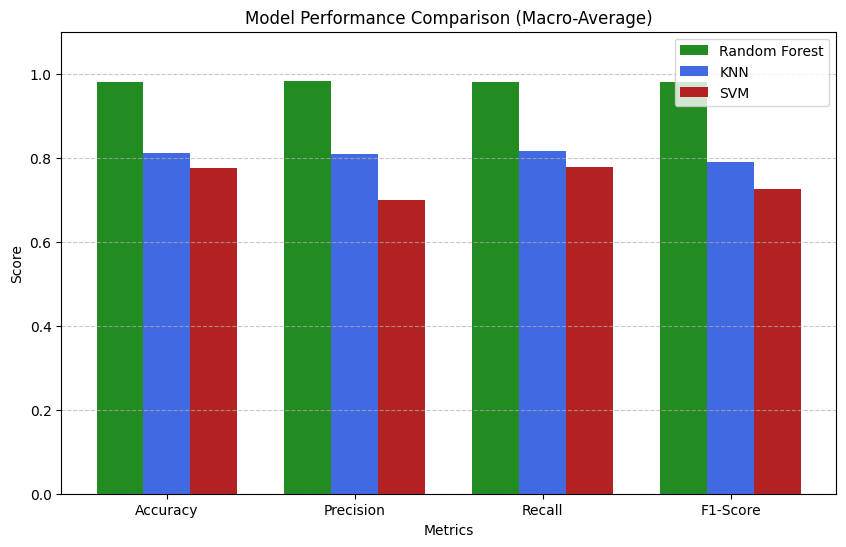

In [ ]:
#พล็อต Bar Plot สำหรับ Precision, Recall, F1-Score แยกตามโมเดล
# พล็อตกราฟแท่งเปรียบเทียบเมตริก
plt.figure(figsize=(10, 6))
bar_width = 0.25
index = range(len(df_metrics.columns))

# สร้างแท่งสำหรับแต่ละโมเดล
plt.bar([i for i in index], df_metrics.loc['Random Forest'], bar_width, label='Random Forest', color='forestgreen')
plt.bar([i + bar_width for i in index], df_metrics.loc['KNN'], bar_width, label='KNN', color='royalblue')
plt.bar([i + 2 * bar_width for i in index], df_metrics.loc['SVM'], bar_width, label='SVM', color='firebrick')

# ตั้งชื่อแกนและหัวเรื่อง
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison (Macro-Average)')
plt.xticks([i + bar_width for i in index], df_metrics.columns)
plt.legend()
plt.ylim(0, 1.1)  # กำหนดช่วงแกน Y เพื่อให้เห็นความแตกต่าง
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

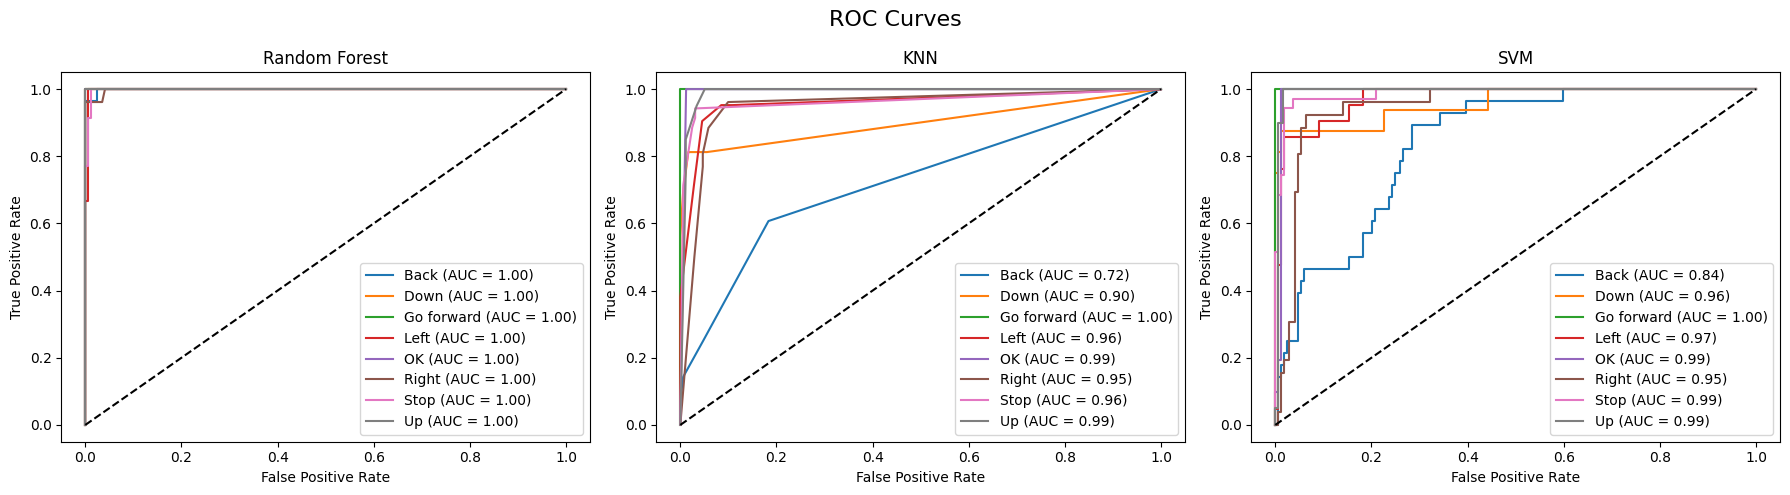

In [20]:
# ส่วนที่ 7: พล็อต ROC Curve สำหรับแต่ละโมเดล
# Binarize เลเบลสำหรับ multi-class ROC
y_test_bin = label_binarize(y_test, classes=classes)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ROC Curves', fontsize=16)

# Random Forest
rf_prob = rf.predict_proba(X_test)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], rf_prob[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# KNN
knn_prob = knn.predict_proba(X_test)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], knn_prob[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], 'k--')
axes[1].set_title('KNN')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

# SVM
svm_prob = svm.predict_proba(X_test)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], svm_prob[:, i])
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')
axes[2].plot([0, 1], [0, 1], 'k--')
axes[2].set_title('SVM')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

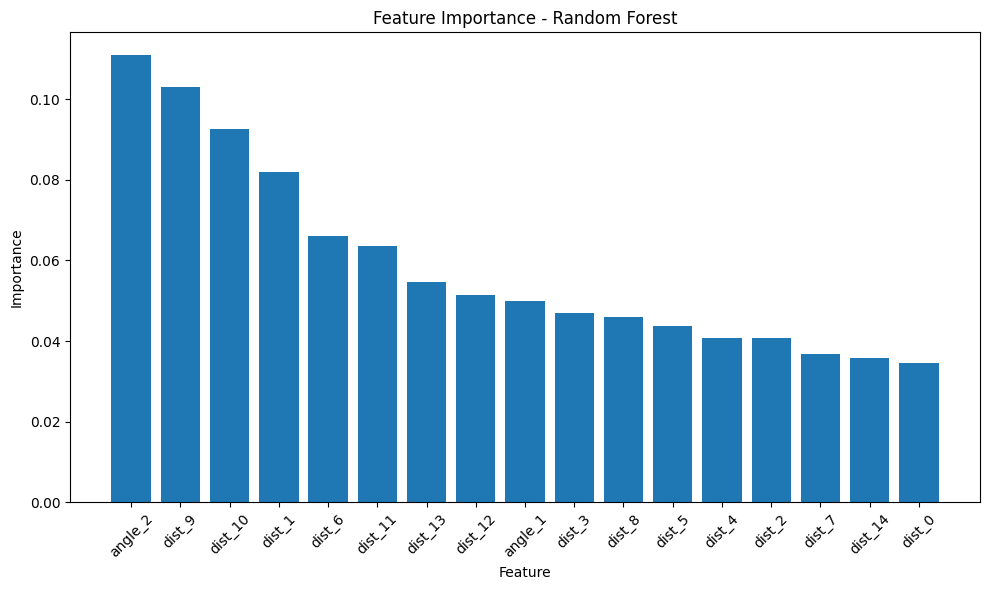

In [21]:
# ส่วนที่ 8: พล็อต Feature Importance สำหรับ Random Forest
feature_names = [f'dist_{i}' for i in range(len(distance_pairs))] + ['angle_1', 'angle_2']
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Random Forest')
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_rf.png')
plt.show()

/Users/aoyrzz/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/aoyrzz/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/aoyrzz/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/Users/aoyrzz/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/svm/_base.py", l

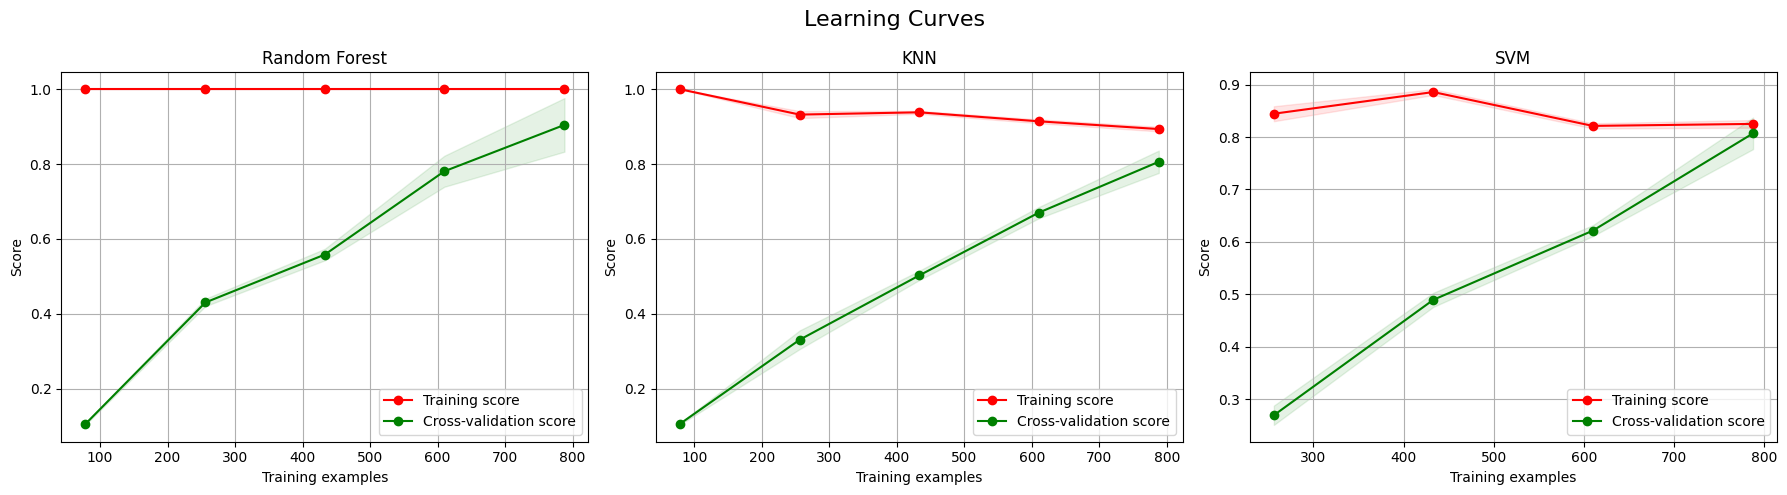

In [22]:
# ส่วนที่ 9: พล็อต Learning Curve สำหรับแต่ละโมเดล
def plot_learning_curve(estimator, title, X, y, ax, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, train_sizes=train_sizes, scoring='accuracy')
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    ax.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    ax.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-validation score')
    ax.fill_between(train_sizes, train_scores_mean - train_scores_std, train_scores_mean + train_scores_std, alpha=0.1, color='r')
    ax.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color='g')
    ax.set_title(title)
    ax.set_xlabel('Training examples')
    ax.set_ylabel('Score')
    ax.legend(loc='best')
    ax.grid(True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves', fontsize=16)

plot_learning_curve(rf, 'Random Forest', X, y, axes[0])
plot_learning_curve(knn, 'KNN', X, y, axes[1])
plot_learning_curve(svm, 'SVM', X, y, axes[2])

plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

In [28]:
# บันทึกโมเดล
import pickle
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn, f)
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)

print("บันทึกโมเดลทั้งสามเรียบร้อย: rf_model.pkl, knn_model.pkl, svm_model.pkl")

บันทึกโมเดลทั้งสามเรียบร้อย: rf_model.pkl, knn_model.pkl, svm_model.pkl
